# Alternating parameter recovery

Oracle-topology, one-physical-scalar-at-a-time recovery from `scripts/5_alternating_parameter_recovery.sh`.

In [187]:
from __future__ import annotations
import json, re
from pathlib import Path
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgba
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'pyproject.toml').is_file():
    raise RuntimeError(f'Expected to run from the repository root, got {REPO_ROOT}')
RESULTS_DIR = REPO_ROOT / 'derived' / 'results' / 'alternating_parameter_recovery'
PATTERN = re.compile(r'^alternating_(?P<dynamic>diffusion|wave)_(?P<topology>[^_]+)_(?P<case>[^_]+)_(?:dtinit(?P<dt_initial>[^_]+)_)?gammainit(?P<gamma_initial>[^_]+)_omegainit(?P<omega_initial>[^_]+)_forceinit(?P<force_scale_initial>[^_]+)_lr(?P<recovery_lr>[^_]+)_top(?P<topology_epochs>\d+)_phys(?P<physical_epochs>\d+)_cycles(?P<cycles>\d+)_epochs(?P<epochs>\d+)_nodes(?P<num_nodes>\d+)_episodes(?P<num_episodes>\d+)_bins(?P<num_bins>\d+)_events(?P<events_per_bin>\d+)_dropint(?P<raindrop_interval>\d+)_seed(?P<seed>\d+)\.jsonl$')
def tag(value): return None if value is None else float(value.replace('p', '.').replace('m', '-'))

def add_fading_path(ax, x, y, *, color, linewidth=1.8, alpha_start=0.12, alpha_end=0.95):
    """Draw a trajectory whose opaque end emphasizes its current estimate."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[valid], y[valid]
    if len(x) < 2:
        return
    points = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    rgba = to_rgba(color)
    colors = [(rgba[0], rgba[1], rgba[2], alpha) for alpha in np.linspace(alpha_start, alpha_end, len(segments))]
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=linewidth, zorder=2))
    ax.scatter(x[0], y[0], s=28, facecolor='white', edgecolor=color, linewidth=1.0, zorder=4)
    ax.scatter(x[-1], y[-1], s=28, facecolor=color, edgecolor=color, linewidth=.8, zorder=4)


In [188]:
def load_results(directory):
    rows = []
    paths = sorted(directory.glob('alternating_diffusion_*.jsonl')) + sorted(directory.glob('alternating_wave_*.jsonl'))
    if not paths: raise FileNotFoundError(f'No alternating JSONLs in {directory}')
    for path in paths:
        match = PATTERN.fullmatch(path.name)
        if match is None: raise ValueError(f'Unexpected alternating filename: {path.name}')
        meta = match.groupdict(); meta['source_file'] = path.name
        for key in ('topology_epochs','physical_epochs','cycles','epochs','num_nodes','num_episodes','num_bins','events_per_bin','raindrop_interval','seed'): meta[key] = int(meta[key])
        for key in ('dt_initial','gamma_initial','omega_initial','force_scale_initial','recovery_lr'): meta[key] = tag(meta[key])
        rows += [{**json.loads(line), **meta} for line in path.read_text().splitlines() if line.strip()]
    return pd.json_normalize(rows, sep='.')

alternating_df = load_results(RESULTS_DIR)
status = alternating_df.groupby('source_file', as_index=False).agg(dynamic=('dynamic','first'), case=('case','first'), logged_epochs=('epoch','max'), expected_epochs=('epochs','first'), phases=('alternating_phase',lambda x: tuple(pd.unique(x.dropna()))))
status['complete'] = status.logged_epochs.eq(status.expected_epochs)
status


,source_file,dynamic,case,logged_epochs,expected_epochs,phases,complete
0,alternating_diffusion_ring_random0_dtinit0p1_g...,diffusion,random0,200,200,"(physical_gamma, physical_force_scale)",True
1,alternating_diffusion_ring_random1_dtinit0p1_g...,diffusion,random1,200,200,"(physical_gamma, physical_force_scale)",True
2,alternating_diffusion_ring_random2_dtinit0p1_g...,diffusion,random2,200,200,"(physical_gamma, physical_force_scale)",True
3,alternating_diffusion_ring_random3_dtinit0p1_g...,diffusion,random3,200,200,"(physical_gamma, physical_force_scale)",True
4,alternating_diffusion_ring_random4_dtinit0p1_g...,diffusion,random4,200,200,"(physical_gamma, physical_force_scale)",True
5,alternating_wave_ring_random0_dtinit0p1_gammai...,wave,random0,300,300,"(physical_omega, physical_gamma, physical_forc...",True
6,alternating_wave_ring_random1_dtinit0p1_gammai...,wave,random1,300,300,"(physical_omega, physical_gamma, physical_forc...",True
7,alternating_wave_ring_random2_dtinit0p1_gammai...,wave,random2,300,300,"(physical_omega, physical_gamma, physical_forc...",True
8,alternating_wave_ring_random3_dtinit0p1_gammai...,wave,random3,300,300,"(physical_omega, physical_gamma, physical_forc...",True
9,alternating_wave_ring_random4_dtinit0p1_gammai...,wave,random4,300,300,"(physical_omega, physical_gamma, physical_forc...",True


In [189]:
TRACE = {'dt': ('parameter_trace.learned_dt','parameter_trace.true_dt',r'$\Delta t$'), 'gamma': ('parameter_trace.learned_gamma','parameter_trace.true_gamma',r'$\gamma$'), 'force_scale': ('parameter_trace.learned_force_scale','parameter_trace.true_force_scale','Force scale'), 'omega': ('parameter_trace.learned_omega','parameter_trace.true_omega',r'$\omega$')}
records=[]
for parameter,(learned,true,label) in TRACE.items():
    if learned not in alternating_df or true not in alternating_df: continue
    for _,row in alternating_df[alternating_df[learned].notna()].iterrows(): records.append({'source_file':row.source_file,'dynamic':row.dynamic,'case':row.case,'epoch':row.epoch,'phase':row.get('alternating_phase'),'parameter':parameter,'initial_value':row[f'{parameter}_initial'],'learned_value':row[learned],'true_value':row[true]})
recovery_long=pd.DataFrame(records).sort_values(['dynamic','source_file','parameter','epoch']).reset_index(drop=True)
recovery_long['relative_value']=recovery_long.learned_value/recovery_long.true_value
recovery_long['is_active'] = recovery_long.phase.eq('physical_' + recovery_long.parameter)
recovery_long['active_epoch'] = recovery_long.groupby(['source_file', 'parameter']).is_active.cumsum()
recovery_active = recovery_long[recovery_long.is_active].copy()
final_recovery=(recovery_long.sort_values('epoch').groupby(['source_file','parameter'],as_index=False).tail(1).assign(abs_error=lambda x:(x.learned_value-x.true_value).abs()).sort_values(['dynamic','case','parameter']))
final_recovery[['dynamic','case','parameter','initial_value','true_value','learned_value','abs_error','epoch']]


,dynamic,case,parameter,initial_value,true_value,learned_value,abs_error,epoch
199,diffusion,random0,dt,0.100000,0.10,0.100000,1.490116e-09,200
399,diffusion,random0,force_scale,0.572721,0.80,0.810648,1.064755e-02,200
599,diffusion,random0,gamma,0.257381,0.18,0.181462,1.461975e-03,200
799,diffusion,random0,omega,0.700000,NaN,0.700000,NaN,200
999,diffusion,random1,dt,0.100000,0.10,0.100000,1.490116e-09,200
1199,diffusion,random1,force_scale,1.063705,0.80,0.809362,9.361875e-03,200
1399,diffusion,random1,gamma,0.169097,0.18,0.180311,3.105921e-04,200
1599,diffusion,random1,omega,0.700000,NaN,0.700000,NaN,200
1799,diffusion,random2,dt,0.100000,0.10,0.100000,1.490116e-09,200
1999,diffusion,random2,force_scale,0.487600,0.80,0.806645,6.644976e-03,200


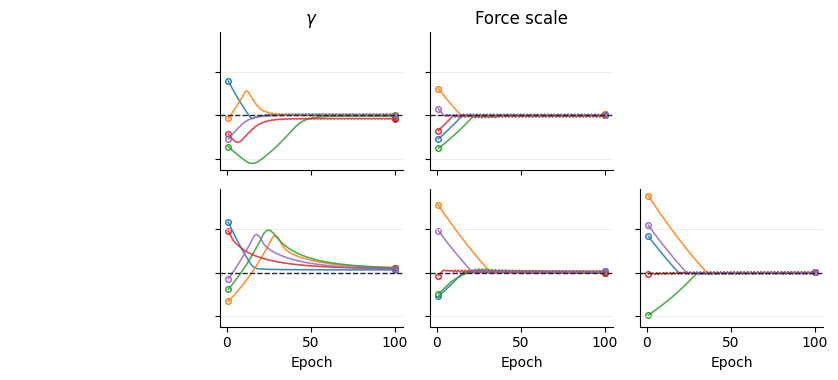

In [190]:
parameters=['dt','gamma','force_scale','omega']; dynamics=['diffusion','wave']
fig,axes=plt.subplots(2,4,figsize=(8.5,3.9),sharex=True,sharey=True)
for i,dynamic in enumerate(dynamics):
    for j,parameter in enumerate(parameters):
        ax=axes[i,j]; data=recovery_active.query('dynamic == @dynamic and parameter == @parameter')
        if data.empty: ax.axis('off'); continue
        for _,trace in data.groupby('source_file'):
            trace=trace.sort_values('active_epoch'); 
            line=ax.plot(trace.active_epoch,trace.relative_value,linewidth=1.15,alpha=.85)[0]; 
            color=line.get_color(); 
            ax.scatter(trace.active_epoch.iloc[0],trace.relative_value.iloc[0],s=16,facecolor='white',edgecolor=color); 
            ax.scatter(trace.active_epoch.iloc[-1],trace.relative_value.iloc[-1],s=16,color=color)
        ax.axhline(1,color='.15',ls='--',lw=1); 
        #ax.set_yscale('log'); 
        ax.set_title(TRACE[parameter][2] if i==0 else ''); ax.set_ylabel(f'{dynamic.title()}\nlearned / true' if j==0 else ''); ax.set_xlabel('Epoch' if i==1 else ''); ax.spines[['top','right']].set_visible(False); ax.grid(axis='y',color='.9',lw=.5)
fig.tight_layout(); plt.show()


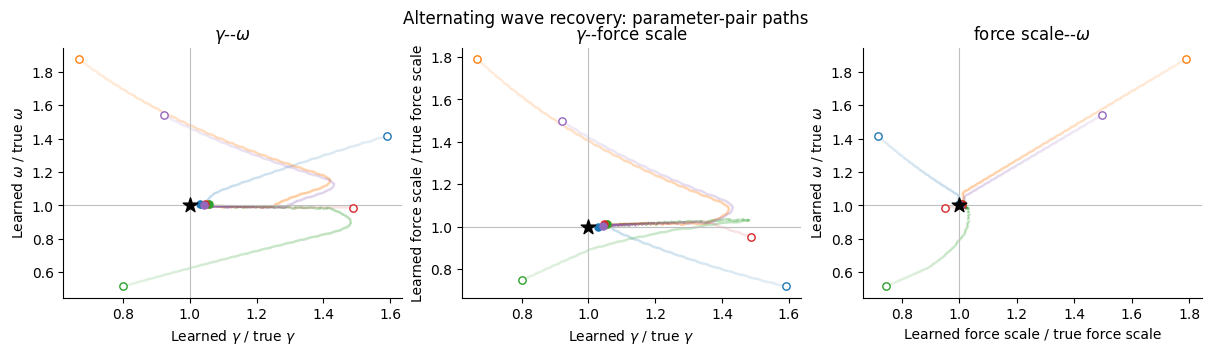

In [193]:
# Every row contains the current value of each scalar; retain all physical-update epochs
# so each pair traces the full alternating trajectory.
wave = recovery_long[recovery_long.dynamic.eq('wave') & recovery_long.phase.str.startswith('physical_')].pivot_table(index=['source_file', 'epoch'], columns='parameter', values='relative_value', aggfunc='first').reset_index()
pairs = [('gamma', 'omega'), ('gamma', 'force_scale'), ('force_scale', 'omega')]
labels = {'gamma': r'$\gamma$', 'omega': r'$\omega$', 'force_scale': 'force scale'}
fig, axes = plt.subplots(1, len(pairs), figsize=(12, 3.3), constrained_layout=True)
for ax, (x_name, y_name) in zip(axes, pairs):
    pair_data = wave.dropna(subset=[x_name, y_name])
    for trace_index, (_, trace) in enumerate(pair_data.groupby('source_file')):
        trace = trace.sort_values('epoch').copy()
        x_smooth = trace[x_name].rolling(5, center=True, min_periods=1).mean()
        y_smooth = trace[y_name].rolling(5, center=True, min_periods=1).mean()
        add_fading_path(ax, x_smooth, y_smooth, color=f'C{trace_index % 10}')
    ax.scatter(1, 1, marker='*', s=120, color='black', zorder=4, label='true value')
    ax.axvline(1, color='.75', lw=.8); ax.axhline(1, color='.75', lw=.8)
    ax.set(xlabel=f'Learned {labels[x_name]} / true {labels[x_name]}', ylabel=f'Learned {labels[y_name]} / true {labels[y_name]}', title=f'{labels[x_name]}--{labels[y_name]}')
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Alternating wave recovery: parameter-pair paths', y=1.03)
plt.show()
